In [1]:
# import libraries
import polars as pl
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from tqdm.notebook import tqdm

from scipy import stats
from datetime import date

# polars display
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_width_chars(200)

# plotly renderer
pio.renderers.default = "png"

# data path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from src.config import RAW_DIR, INTERIM_DIR, PROCESSED_DIR, DOCS_DIR

# warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load data
df = pl.scan_parquet(PROCESSED_DIR / "modelling_base.parquet")

# default column
df = df.with_columns(pl.when(pl.col("loan_status") == pl.lit("paid"))
                        .then(pl.lit(0))
                        .otherwise(pl.lit(1))
                        .alias("default"))

df.head().collect()

loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,loan_status,issue_d,default
i64,i64,f64,i64,f64,f64,cat,cat,i64,cat,f64,cat,cat,str,cat,f64,i64,date,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,cat,i64,i64,cat,i64,f64,f64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,f64,cat,date,i32
12000,12000,12000.0,36,7.97,375.88,"""A""","""A5""",null,"""OWN""",42000.0,"""Source Verified""","""debt_consolidation""","""923xx""","""CA""",27.74,0,1996-06-01,715,719,0,null,80,9,1,11457.0,37.0,16,"""w""",0,null,"""Individual""",0,0.0,30502.0,1,2,1,3,8,19045.0,73.0,2,4,7117.0,53.0,31000.0,1,1,2,7,3389.0,7144.0,53.9,0,0.0,131,255,1,1,0,14,null,8,null,0,2,6,2,2,7,7,9,6,9,0,0,0,3,100.0,0.0,1,0,57180.0,30502.0,15500.0,26180.0,"""paid""",2017-09-01,0
10000,10000,10000.0,36,9.44,320.05,"""B""","""B1""",3,"""MORTGAGE""",55000.0,"""Not Verified""","""debt_consolidation""","""971xx""","""OR""",18.79,0,2005-09-01,695,699,0,68,99,7,1,7188.0,57.5,10,"""w""",0,null,"""Individual""",0,0.0,340607.0,0,4,1,2,10,209187.0,75.0,0,0,6847.0,68.0,12500.0,1,1,1,3,48658.0,3653.0,65.2,0,0.0,144,73,49,10,2,49,null,8,68,0,1,2,1,1,5,2,3,2,7,0,0,0,1,100.0,0.0,1,0,315034.0,216375.0,10500.0,175048.0,"""paid""",2017-09-01,0
8000,8000,8000.0,36,16.02,281.34,"""C""","""C5""",0,"""MORTGAGE""",120000.0,"""Not Verified""","""debt_consolidation""","""136xx""","""NY""",20.36,0,1994-09-01,700,704,1,64,null,8,0,19015.0,92.3,34,"""w""",0,null,"""Joint App""",0,0.0,388595.0,2,3,2,5,6,83572.0,85.0,0,0,0.0,88.0,20600.0,1,24,2,6,55514.0,null,null,0,0.0,137,276,34,6,6,152,null,3,null,0,0,3,1,2,19,4,9,3,8,0,0,0,3,97.1,null,0,0,400558.0,102587.0,0.0,89958.0,"""paid""",2017-09-01,0
12800,12800,12800.0,36,13.59,434.93,"""C""","""C2""",5,"""RENT""",90000.0,"""Not Verified""","""debt_consolidation""","""799xx""","""TX""",22.63,0,1988-12-01,660,664,2,43,null,10,0,12660.0,86.0,23,"""w""",0,94,"""Individual""",0,0.0,93375.0,2,3,2,3,6,80715.0,91.0,1,3,3777.0,86.0,14750.0,0,1,2,6,10375.0,2458.0,86.0,0,0.0,154,345,5,5,0,5,null,5,null,0,6,6,6,6,15,6,8,6,9,null,0,0,3,83.0,83.3,0,0,103040.0,93375.0,14750.0,88290.0,"""paid""",2017-09-01,0
15000,15000,15000.0,36,13.59,509.69,"""C""","""C2""",4,"""MORTGAGE""",180000.0,"""Source Verified""","""medical""","""757xx""","""TX""",38.07,0,1976-12-01,680,684,0,null,null,24,0,107214.0,66.6,50,"""w""",0,null,"""Individual""",0,0.0,682000.0,0,4,0,3,13,190233.0,79.0,0,1,22127.0,68.0,161100.0,2,8,0,5,29652.0,16347.0,86.0,0,0.0,132,489,16,13,4,16,null,13,null,0,10,14,11,16,17,19,29,14,24,0,0,0,0,100.0,72.7,0,0,769704.0,297447.0,116700.0,221207.0,"""paid""",2017-09-01,0


# 6. EDA: Temporal Stability and Synthesis

**Main Objective**

Assess whether portfolio risk and key risk-driver relationships remain reasonably stable across loan vintages.

## 6.1 Portfolio Trend

In [4]:
portfolio_trend = (
    df
    .with_columns(
        pl.col("issue_d").dt.year().alias("issue_year")
    )
    .group_by("issue_year")
    .agg(
        pl.len().alias("loan_volume"),
        pl.col("funded_amnt").sum().alias("funded_amount"),
        pl.col("default").mean().alias("default_rate"),
        pl.col("int_rate").mean().alias("avg_int_rate"),
    )
    .sort("issue_year")
    .collect()
)

portfolio_trend

issue_year,loan_volume,funded_amount,default_rate,avg_int_rate
i32,u32,i64,f64,f64
2016,403104,5761212675,0.196183,12.88793
2017,314368,4474695375,0.210734,13.295874
2018,197178,3023428600,0.239515,13.154397
2019,75405,1126930575,0.179895,13.582556
2020,4286,59130275,0.013532,13.799225


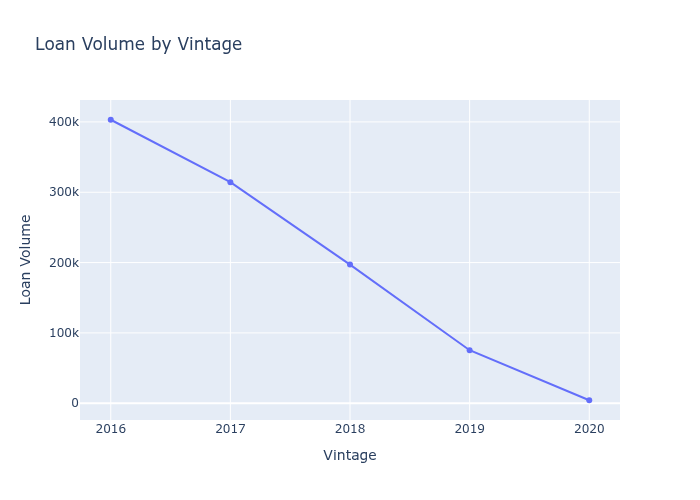

In [5]:
fig = px.line(
    portfolio_trend,
    x="issue_year",
    y="loan_volume",
    markers=True,
    title="Loan Volume by Vintage",
    labels={
        "issue_year": "Vintage",
        "loan_volume": "Loan Volume",
    },
)

fig.show()

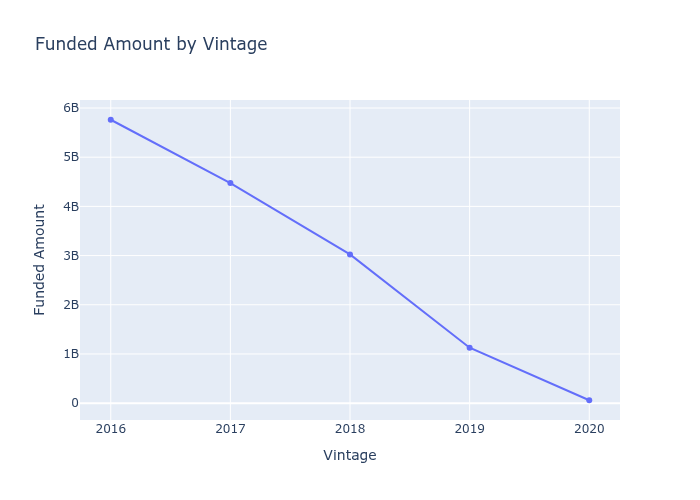

In [6]:
fig = px.line(
    portfolio_trend,
    x="issue_year",
    y="funded_amount",
    markers=True,
    title="Funded Amount by Vintage",
    labels={
        "issue_year": "Vintage",
        "funded_amount": "Funded Amount",
    },
)

fig.show()

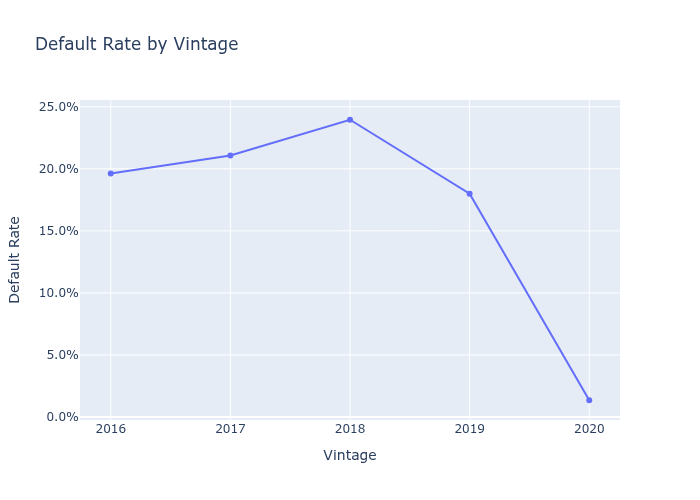

In [7]:
fig = px.line(
    portfolio_trend,
    x="issue_year",
    y="default_rate",
    markers=True,
    title="Default Rate by Vintage",
    labels={
        "issue_year": "Vintage",
        "default_rate": "Default Rate",
    },
)

fig.update_yaxes(tickformat=".1%")

fig.show()

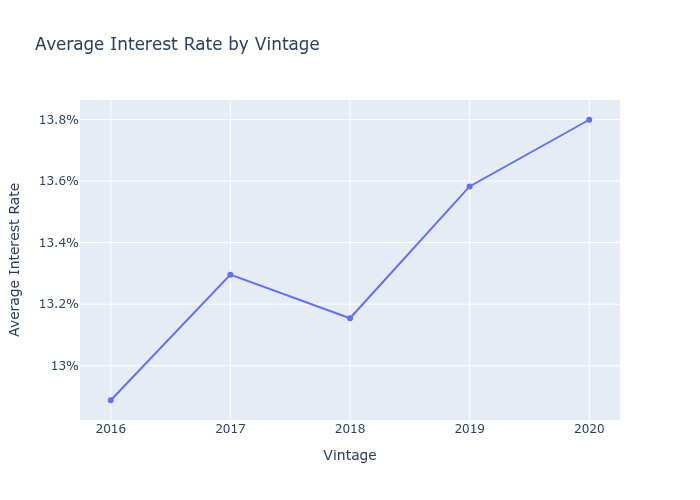

In [8]:
fig = px.line(
    portfolio_trend,
    x="issue_year",
    y="avg_int_rate",
    markers=True,
    title="Average Interest Rate by Vintage",
    labels={
        "issue_year": "Vintage",
        "avg_int_rate": "Average Interest Rate",
    },
)

fig.update_yaxes(ticksuffix="%")

fig.show()

In [10]:
grade_trend = (
    df
    .with_columns(
        pl.col("issue_d").dt.year().alias("issue_year")
    )
    .group_by(["issue_year", "grade"])
    .agg(
        pl.len().alias("loan_volume")
    )
    .with_columns(
        (
            pl.col("loan_volume")
            / pl.col("loan_volume").sum().over("issue_year")
        ).alias("share")
    )
    .sort(["issue_year", "grade"])
    .collect()
)

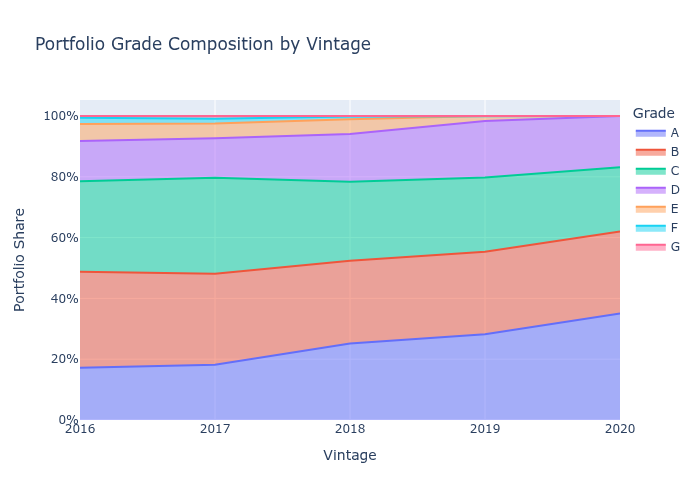

In [11]:
grade_pd = grade_trend.to_pandas()

fig = px.area(
    grade_pd,
    x="issue_year",
    y="share",
    color="grade",
    groupnorm="fraction",
    title="Portfolio Grade Composition by Vintage",
    labels={
        "issue_year": "Vintage",
        "share": "Portfolio Share",
        "grade": "Grade",
    },
)

fig.update_yaxes(tickformat=".0%")

fig.show()

### **Portfolio Trend Analysis**

* **Portfolio volume contracted significantly over time.** Loan volume declined from **403K in 2016 to 75K in 2019**, while funded amount fell from **$5.76B to $1.13B**. This indicates a substantial reduction in portfolio origination activity.

* **Risk increased from 2016 to 2018.** Default rate rose from **19.6% in 2016 to 24.0% in 2018**, while average interest rate remained relatively stable around **13%**. The increase in observed default risk therefore was not simply accompanied by a major change in pricing.

* **The 2019 vintage shows an improvement in observed default rate.** Default rate declined to **18.0%**, despite the average interest rate increasing to **13.6%**. This improvement coincides with a major shift toward higher-grade loans.

* **Portfolio composition became progressively more conservative.** Grade A increased from **17.2% of loans in 2016 to 28.2% in 2019**, while Grade C declined from **29.7% to 24.5%**. Lower-grade exposure also contracted substantially, particularly Grades E to G.

* **The grade mix provides an important explanation for the temporal risk pattern.** The increase in A-grade loans and reduction in lower-grade loans from 2018 onward is consistent with the decline in observed default rate in 2019. Therefore, part of the change in portfolio risk appears to be driven by **portfolio composition**, not necessarily a change in the underlying risk relationship.

* **2020 should not be interpreted as a normal vintage.** Only **4,286 loans** are present, with a default rate of **1.35%**, which is dramatically below previous vintages. This is likely driven by **incomplete outcome maturity**, since recent loans have had insufficient time to reach default. It should therefore be excluded from direct default-rate trend interpretation or treated separately.

### **Overall conclusion**

> The portfolio became smaller and increasingly concentrated in higher-grade borrowers over the observed period. Default risk increased through 2018 but improved substantially in 2019 alongside a more conservative grade mix. The 2020 default rate is not comparable because of vintage maturity, making **2016 to 2019 the more meaningful period for temporal risk analysis**.

**Modeling implication:** Temporal analysis should distinguish **portfolio composition changes** from **changes in feature-to-default relationships**. This supports the next step of checking risk-driver stability across vintages before feature engineering.


## 6.2 Risk Driver and Feature Stability

### 6.2.1 Feature Distribution

In [16]:
STABILITY_FEATURES = [
    "fico_range_low",
    "int_rate",
    "dti",
    "loan_amnt",
    "revol_util",
]

In [17]:
feature_stability = (
    df
    .with_columns(
        pl.col("issue_d").dt.year().alias("issue_year")
    )
    .group_by("issue_year")
    .agg(
        *[
            pl.col(feature).median().alias(f"{feature}_median")
            for feature in STABILITY_FEATURES
        ],
        *[
            pl.col(feature).is_null().mean().alias(f"{feature}_missing")
            for feature in STABILITY_FEATURES
        ],
    )
    .sort("issue_year")
)

feature_stability_pd = feature_stability.collect().to_pandas()

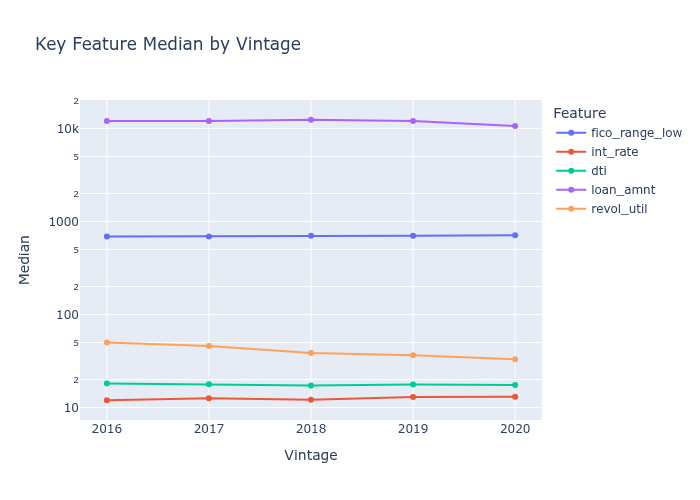

In [33]:
median_cols = [
    f"{feature}_median"
    for feature in STABILITY_FEATURES
]

median_trend = feature_stability_pd.melt(
    id_vars="issue_year",
    value_vars=median_cols,
    var_name="feature",
    value_name="median",
)

median_trend["feature"] = (
    median_trend["feature"]
    .str.replace("_median", "", regex=False)
)

fig = px.line(
    median_trend,
    x="issue_year",
    y="median",
    color="feature",
    markers=True,
    title="Key Feature Median by Vintage",
    labels={
        "issue_year": "Vintage",
        "median": "Median",
        "feature": "Feature",
    },
)

fig.update_yaxes(type="log")
fig.show()

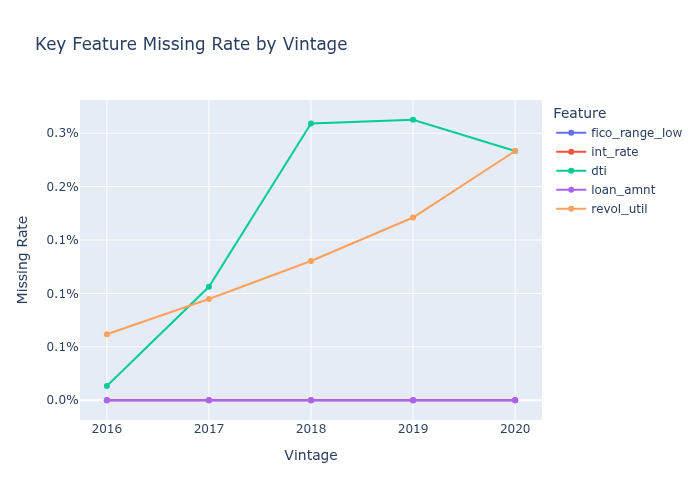

In [19]:
missing_cols = [
    f"{feature}_missing"
    for feature in STABILITY_FEATURES
]

missing_trend = feature_stability_pd.melt(
    id_vars="issue_year",
    value_vars=missing_cols,
    var_name="feature",
    value_name="missing_rate",
)

missing_trend["feature"] = (
    missing_trend["feature"]
    .str.replace("_missing", "", regex=False)
)

fig = px.line(
    missing_trend,
    x="issue_year",
    y="missing_rate",
    color="feature",
    markers=True,
    title="Key Feature Missing Rate by Vintage",
    labels={
        "issue_year": "Vintage",
        "missing_rate": "Missing Rate",
        "feature": "Feature",
    },
)

fig.update_yaxes(tickformat=".1%")
fig.show()

### 6.2.2 Risk Relationship Stability

In [21]:
import pandas as pd

risk_features = [
    "fico_range_low",
    "int_rate",
    "dti",
    "loan_amnt",
    "revol_util",
]

df_stability = (
    df
    .with_columns(
        pl.col("issue_d").dt.year().alias("issue_year")
    )
    .collect()
    .to_pandas()
)

for feature in risk_features:
    df_stability[f"{feature}_bin"] = pd.qcut(
        df_stability[feature],
        q=5,
        duplicates="drop",
    )

In [22]:
risk_stability = []

for feature in risk_features:
    temp = (
        df_stability
        .dropna(subset=[feature])
        .groupby(
            ["issue_year", f"{feature}_bin"],
            observed=True
        )
        .agg(
            default_rate=("default", "mean"),
            loan_volume=("default", "size"),
        )
        .reset_index()
    )

    temp["feature"] = feature
    temp["bin"] = temp[f"{feature}_bin"].astype(str)

    risk_stability.append(
        temp[
            [
                "issue_year",
                "feature",
                "bin",
                "default_rate",
                "loan_volume",
            ]
        ]
    )

risk_stability = pd.concat(
    risk_stability,
    ignore_index=True,
)

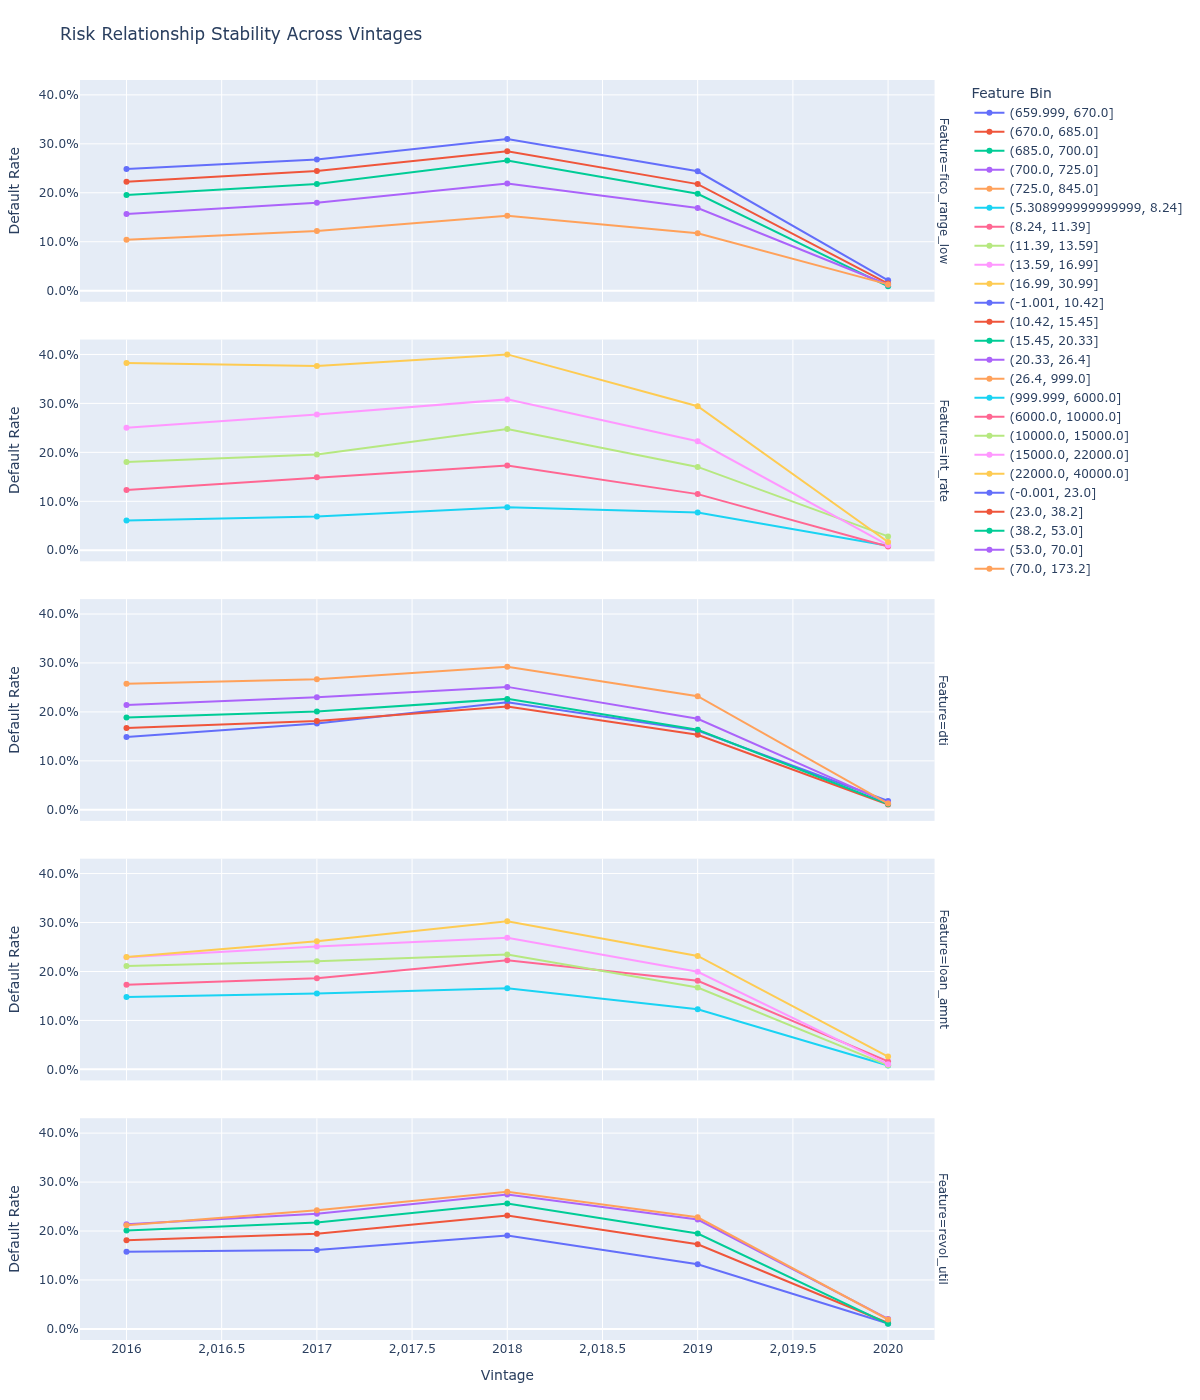

In [24]:
fig = px.line(
    risk_stability,
    x="issue_year",
    y="default_rate",
    color="bin",
    facet_row="feature",
    markers=True,
    title="Risk Relationship Stability Across Vintages",
    labels={
        "issue_year": "Vintage",
        "default_rate": "Default Rate",
        "bin": "Feature Bin",
        "feature": "Feature",
    },
    height=1400,
    width=1200,
)

fig.update_yaxes(tickformat=".1%")

fig.update_layout(
    legend_title_text="Feature Bin",
    margin=dict(t=80, b=60, l=80, r=40),
)

fig.show()

### 6.2.3 Analysis and Summary


* **The main risk relationships are directionally stable across 2016 to 2019.** FICO, interest rate, DTI, loan amount, and revolving utilization generally maintain consistent risk gradients, supporting their use as candidate PD features.

* **FICO shows the strongest and most consistent relationship.** Default rates decline monotonically as FICO increases in every mature vintage. For example, in 2019 default rate falls from **24.4% in the lowest FICO bin to 11.7% in the highest bin**. This indicates a robust credit-quality signal.

* **Interest rate also has a strong, persistent risk gradient.** Higher-rate loans consistently exhibit higher default rates. In 2019, the rate ranges from **7.7% in the lowest rate bin to 29.4% in the highest**. The relationship is strong across 2016 to 2019, although interest rate should be interpreted as both a risk indicator and a lender-assigned pricing variable.

* **DTI maintains a positive relationship with default, but with weaker separation.** Higher DTI generally corresponds to higher default risk, with the highest DTI bin reaching **23.2% in 2019 versus 16.2% in the lowest bin**. The relationship is less monotonic in the middle bins, suggesting a potentially nonlinear effect.

* **Loan amount shows a generally positive risk relationship.** Larger loans tend to have higher default rates, particularly in 2016 to 2018. The pattern remains directionally consistent in 2019, although the middle bins show some variation. This supports retaining the feature while allowing the model to capture nonlinear effects.

* **Revolving utilization has a consistent but moderate relationship.** Default rates generally increase with utilization, reaching **22.8% in the highest bin in 2019 versus 13.2% in the lowest bin**. The highest utilization bins show some flattening, suggesting a nonlinear or threshold effect.

* **Feature quality is highly stable.** FICO, interest rate, and loan amount have **0% missingness** across all vintages. DTI remains below **0.3% missingness**, while revolving utilization increases gradually from **0.06% to 0.23%**, still negligible for modeling.

* **2020 should be excluded from risk-relationship stability conclusions.** All features show dramatically lower default rates in 2020, consistent with the previously observed **1.35% overall default rate** and the small, immature vintage. Including it would incorrectly suggest that the feature-risk relationships suddenly disappeared.

#### Overall conclusion

> **The selected risk drivers demonstrate reasonable temporal stability from 2016 to 2019.** FICO and interest rate show the strongest and most consistent risk gradients, while DTI, loan amount, and revolving utilization provide additional but potentially nonlinear signals. Feature missingness is negligible and stable. These results support proceeding to **Feature Engineering**, while preserving nonlinear relationships where appropriate.

#### Modeling implications

| Feature          | Distribution / Quality       | Risk Stability      | Decision   |
| ---------------- | ---------------------------- | ------------------- | ---------- |
| `fico_range_low` | Very stable                  | Strong, monotonic   | **Retain** |
| `int_rate`       | Very stable                  | Strong, monotonic   | **Retain** |
| `dti`            | Stable, <0.3% missing        | Moderate, positive  | **Retain** |
| `loan_amnt`      | Very stable                  | Moderate, nonlinear | **Retain** |
| `revol_util`     | Stable, very low missingness | Moderate, nonlinear | **Retain** |
